# Paper-matched 6-PLD versus 4-PLD comparison

This notebook generates exactly 10,000 held-out samples using the same reference simulation and compares the separately trained CBF/ATT model pairs.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from IPython.display import display
project_root=Path.cwd().parent if not (Path.cwd()/'src').exists() else Path.cwd(); sys.path.insert(0,str(project_root/'src'))
from simulation import SimulationConfig, generate_dataset, select_inputs, noisy_signals, RESULTS
cfg=SimulationConfig(); print('PLDs 4:',cfg.plds_4_s,'PLDs 6:',cfg.plds_6_s)
print('SNR sweep:', list(range(10, 81, 5)))

PLDs 4: (1.525, 2.025, 2.525, 3.025) PLDs 6: (1.525, 2.025, 2.525, 3.025, 3.525, 4.025)
SNR sweep: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]


In [2]:
X_full,Y_test,_=generate_dataset(10000,cfg,seed=999,snr=10.0); X6=select_inputs(X_full,cfg,'6_pld'); X4=select_inputs(X_full,cfg,'4_pld')
print('Full:',X_full.shape,'6-PLD:',X6.shape,'4-PLD:',X4.shape,'targets:',Y_test.shape)
class StandardizedNet(nn.Module):
    def __init__(self,input_dim,width):
        super().__init__(); layers=[nn.Linear(input_dim,width),nn.ELU()]
        for _ in range(8): layers += [nn.Linear(width,width),nn.ELU()]
        layers.append(nn.Linear(width,1)); self.backbone=nn.Sequential(*layers)
    def forward(self,x): return self.backbone(x)
def load_pair(folder,input_dim):
    norm=np.load(RESULTS/folder/'normalization.npz'); cbf=StandardizedNet(input_dim,50); att=StandardizedNet(input_dim,100)
    cbf.load_state_dict(torch.load(RESULTS/folder/'cbf_model.pt',weights_only=True)); att.load_state_dict(torch.load(RESULTS/folder/'att_model.pt',weights_only=True)); cbf.eval(); att.eval(); return cbf,att,norm
CBF6,ATT6,norm6=load_pair('model_6_pld',6); CBF4,ATT4,norm4=load_pair('model_4_pld',4)
print('Loaded both CBF/ATT pairs.')

Full: (10000, 6) 6-PLD: (10000, 6) 4-PLD: (10000, 4) targets: (10000, 2)


Loaded both CBF/ATT pairs.


## 4A. Train a separate 3-PLD model

The 3-PLD subset is early + middle + late from the reference PLDs: indices `(0, 1, 3)`, corresponding to `(1.525, 2.025, 3.025 s)`. It receives only these three signals.

In [ ]:
def predict_pair(cbf_net,att_net,x,norm):
    xn=((x-norm['X_mean'])/norm['X_std']).astype('float32')
    with torch.no_grad():
        cbf=cbf_net(torch.from_numpy(xn)).squeeze(1).numpy()*float(norm['CBF_std'])+float(norm['CBF_mean']); att=att_net(torch.from_numpy(xn)).squeeze(1).numpy()*float(norm['ATT_std'])+float(norm['ATT_mean'])
    return np.column_stack((np.clip(cbf,0,100),np.clip(att,.5,3.0)))
pred6=predict_pair(CBF6,ATT6,X6,norm6); pred4=predict_pair(CBF4,ATT4,X4,norm4)
np.savez(RESULTS/'comparison_10000_predictions.npz',targets=Y_test,predictions_6_pld=pred6,predictions_4_pld=pred4)
def calc(y,p):
    e=p-y; return {'MAE':np.mean(abs(e)),'RMSE':np.sqrt(np.mean(e**2)),'MAPE_percent':np.mean(abs(e)/np.maximum(abs(y),1e-8))*100,'R2':r2_score(y,p),'Pearson':np.corrcoef(y,p)[0,1],'Bias':np.mean(e),'Error_SD':np.std(e,ddof=1)}
rows=[]
for name,pred in [('6 PLD',pred6),('4 PLD',pred4)]:
    for j,param in enumerate(['CBF','ATT']): row={'Model':name,'Parameter':param}; row.update(calc(Y_test[:,j],pred[:,j])); rows.append(row)
metrics_table=pd.DataFrame(rows); metrics_table.to_csv(RESULTS/'comparison_10000_metrics.csv',index=False); display(metrics_table.round(5))

,Model,Parameter,MAE,RMSE,MAPE_percent,R2,Pearson,Bias,Error_SD
0,6 PLD,CBF,3.70323,4.95753,66.664398,0.97052,0.98545,0.41485,4.94039
1,6 PLD,ATT,0.25818,0.39233,24.676701,0.70235,0.84267,0.06093,0.38759
2,4 PLD,CBF,3.60514,4.82469,65.023888,0.97208,0.98599,-0.28240,4.81666
3,4 PLD,ATT,0.25053,0.38116,23.786060,0.71906,0.85084,0.04954,0.37794


## 4A. Train a separate 3-PLD model

The 3-PLD subset is early + middle + late from the reference PLDs: indices `(0, 1, 3)`, corresponding to `(1.525, 2.025, 3.025 s)`. It receives only these three signals.

In [ ]:
THREE_PLD_INDICES=(0,1,3); THREE_PLD_VALUES=tuple(cfg.plds_4_s[i] for i in THREE_PLD_INDICES); X3=X_full[:,THREE_PLD_INDICES]
train_full,train_targets,_=generate_dataset(4000,cfg,seed=52,snr=10.0); val_full,val_targets,_=generate_dataset(1000,cfg,seed=62,snr=10.0)
train_x3=train_full[:,THREE_PLD_INDICES]; val_x3=val_full[:,THREE_PLD_INDICES]; x3_mean=train_x3.mean(0,keepdims=True).astype(np.float32); x3_std=train_x3.std(0,keepdims=True).astype(np.float32)+1e-8
train_x3=((train_x3-x3_mean)/x3_std).astype(np.float32); val_x3=((val_x3-x3_mean)/x3_std).astype(np.float32); cbf_mean,cbf_std=float(train_targets[:,0].mean()),float(train_targets[:,0].std()+1e-8); att_mean,att_std=float(train_targets[:,1].mean()),float(train_targets[:,1].std()+1e-8)
def train_three_pld(net,x_train,y_train,x_val,y_val,target_mean,target_std,name):
    yt=((y_train-target_mean)/target_std).astype(np.float32); yv=((y_val-target_mean)/target_std).astype(np.float32); tr=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(torch.from_numpy(x_train),torch.from_numpy(yt[:,None])),batch_size=512,shuffle=True); va=torch.utils.data.DataLoader(torch.utils.data.TensorDataset(torch.from_numpy(x_val),torch.from_numpy(yv[:,None])),batch_size=512); opt=torch.optim.Adam(net.parameters(),lr=1e-3); loss_fn=nn.L1Loss(); best=float('inf'); state={k:v.detach().clone() for k,v in net.state_dict().items()}; stale=0; history=[]
    for epoch in range(1,201):
        net.train(); train_loss=0
        for xb,yb in tr:
            opt.zero_grad(); loss=loss_fn(net(xb),yb); loss.backward(); torch.nn.utils.clip_grad_norm_(net.parameters(),1.0); opt.step(); train_loss+=loss.item()
        net.eval(); val_loss=sum(loss_fn(net(xb),yb).item() for xb,yb in va)/len(va); train_loss/=len(tr); history.append({'epoch':epoch,'train_mae':train_loss,'validation_mae':val_loss}); print(f'{name} epoch {epoch:03d}/200 train={train_loss:.6f} val={val_loss:.6f}')
        if val_loss<best: best=val_loss; state={k:v.detach().clone() for k,v in net.state_dict().items()}; stale=0
        else:
            stale+=1
            if stale>=20: print(name,'early stopped at',epoch); break
    net.load_state_dict(state); return pd.DataFrame(history)
CBF3=StandardizedNet(3,50); ATT3=StandardizedNet(3,100); CBF3_history=train_three_pld(CBF3,train_x3,train_targets[:,0],val_x3,val_targets[:,0],cbf_mean,cbf_std,'CBF-3PLD'); ATT3_history=train_three_pld(ATT3,train_x3,train_targets[:,1],val_x3,val_targets[:,1],att_mean,att_std,'ATT-3PLD')
norm3={'X_mean':x3_mean,'X_std':x3_std,'CBF_mean':cbf_mean,'CBF_std':cbf_std,'ATT_mean':att_mean,'ATT_std':att_std}; pred3=predict_pair(CBF3,ATT3,X3,norm3); print('3-PLD values:',THREE_PLD_VALUES); print('3-PLD prediction shape:',pred3.shape)

In [ ]:
three_rows=[]
for j,param in enumerate(['CBF','ATT']):
    row={'Model':'3 PLD','Parameter':param}; row.update(calc(Y_test[:,j],pred3[:,j])); three_rows.append(row)
metrics_table=pd.concat([metrics_table,pd.DataFrame(three_rows)],ignore_index=True)
metrics_table.to_csv(RESULTS/'comparison_10000_metrics.csv',index=False)
print('Final 6/4/3 PLD metrics:')
display(metrics_table.round(5))

## 4A. Train a separate 3-PLD model

The 3-PLD subset is early + middle + late from the reference PLDs: indices `(0, 1, 3)`, corresponding to `(1.525, 2.025, 3.025 s)`. It receives only these three signals.

,Parameter,MAE_change_percent,RMSE_change_percent,R2_change_percent,Pearson_change_percent
0,CBF,-2.64860,-2.67970,0.16061,0.05434
1,ATT,-2.96309,-2.84781,2.37940,0.96924


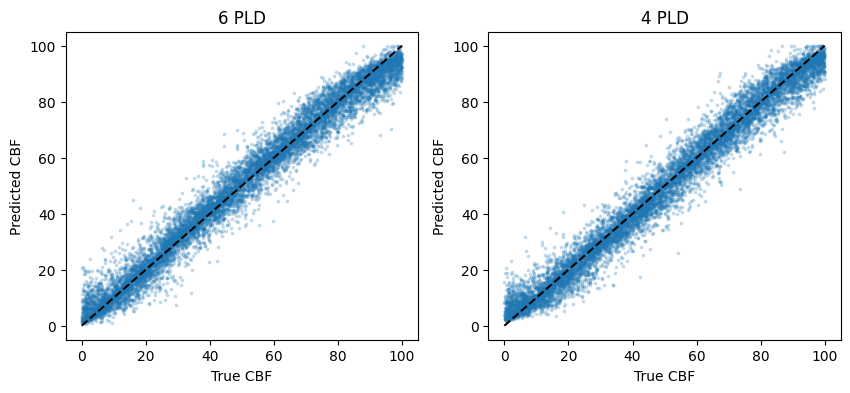

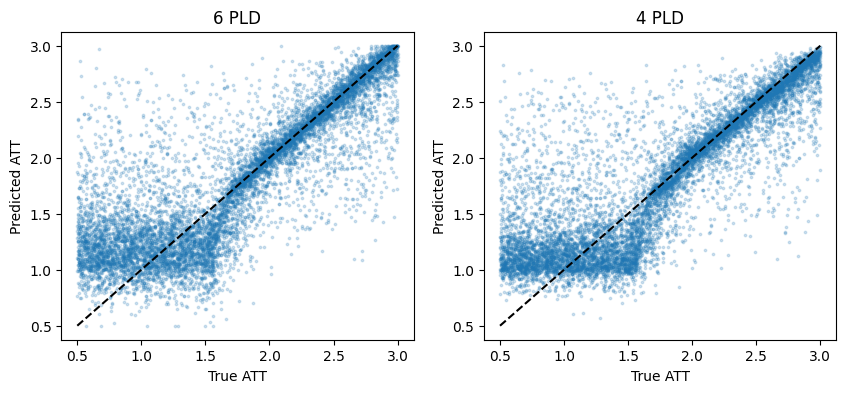

CBF: 6 MAE=3.7032; 4 MAE=3.6051; change=-2.65%
ATT: 6 MAE=0.2582; 4 MAE=0.2505; change=-2.96%


In [ ]:
relative=[]
for param in ['CBF','ATT']:
    base=metrics_table[(metrics_table.Model=='6 PLD')&(metrics_table.Parameter==param)].iloc[0]
    for model_name in ['4 PLD','3 PLD']:
        reduced=metrics_table[(metrics_table.Model==model_name)&(metrics_table.Parameter==param)].iloc[0]
        relative.append({'Model':model_name,'Parameter':param,'MAE_change_percent':(reduced.MAE-base.MAE)/base.MAE*100,'RMSE_change_percent':(reduced.RMSE-base.RMSE)/base.RMSE*100,'R2_change_percent':(reduced.R2-base.R2)/max(abs(base.R2),1e-8)*100,'Pearson_change_percent':(reduced.Pearson-base.Pearson)/max(abs(base.Pearson),1e-8)*100})
relative_table=pd.DataFrame(relative); relative_table.to_csv(RESULTS/'comparison_10000_relative.csv',index=False); display(relative_table.round(5))
plot_dir=RESULTS/'comparison_10000_plots'; plot_dir.mkdir(parents=True,exist_ok=True)
for j,param in enumerate(['CBF','ATT']):
    fig,axes=plt.subplots(1,3,figsize=(14,4));
    for ax,pred,title in zip(axes,[pred6,pred4,pred3],['6 PLD','4 PLD','3 PLD']):
        ax.scatter(Y_test[:,j],pred[:,j],s=3,alpha=.2); lo,hi=Y_test[:,j].min(),Y_test[:,j].max(); ax.plot([lo,hi],[lo,hi],'k--'); ax.set_title(title); ax.set_xlabel('True '+param); ax.set_ylabel('Predicted '+param)
    fig.savefig(plot_dir/f'{param.lower()}_predicted_vs_truth.png',dpi=150); plt.show()
for param in ['CBF','ATT']:
    print(param)
    display(metrics_table[metrics_table.Parameter==param][['Model','MAE','RMSE','R2','Pearson']].round(5))

## 8. Controlled SNR sweep: 10 to 80

The same 10,000 physiological targets are reused at every SNR. Only the Rician noise SD changes, using `noise_SD = reference_signal / SNR`. RMSE, MAE, and Lin's CCC are reported for CBF and ATT.

In [ ]:
def lins_ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64); y_pred = np.asarray(y_pred, dtype=np.float64)
    mean_true, mean_pred = y_true.mean(), y_pred.mean(); covariance = np.mean((y_true-mean_true)*(y_pred-mean_pred)); denominator = y_true.var()+y_pred.var()+(mean_true-mean_pred)**2
    return float(2.0*covariance/denominator) if denominator>0 else np.nan
SNR_LEVELS=list(range(10,81,5)); snr_rows=[]
for snr in SNR_LEVELS:
    exact_snr=np.full(len(Y_test),float(snr),dtype=np.float32); noisy_full=noisy_signals(Y_test[:,0],Y_test[:,1],exact_snr,cfg,rng=np.random.default_rng(10000+snr))
    predictions={'6 PLD':predict_pair(CBF6,ATT6,select_inputs(noisy_full,cfg,'6_pld'),norm6),'4 PLD':predict_pair(CBF4,ATT4,select_inputs(noisy_full,cfg,'4_pld'),norm4),'3 PLD':predict_pair(CBF3,ATT3,noisy_full[:,THREE_PLD_INDICES],norm3)}
    for model_name,prediction in predictions.items():
        for index,parameter in enumerate(['CBF','ATT']):
            truth=Y_test[:,index]; error=prediction[:,index]-truth; snr_rows.append({'SNR':snr,'Model':model_name,'Parameter':parameter,'RMSE':float(np.sqrt(np.mean(error**2))),'MAE':float(np.mean(np.abs(error))),'CCC':lins_ccc(truth,prediction[:,index])})
snr_metrics=pd.DataFrame(snr_rows); snr_metrics.to_csv(RESULTS/'snr_10_to_80_metrics.csv',index=False); print('Rows:',len(snr_metrics)); display(snr_metrics.round(5))

Rows: 60


,SNR,Model,Parameter,RMSE,MAE,CCC
0,10,6 PLD,CBF,4.41270,3.49781,0.98799
1,10,6 PLD,ATT,0.40008,0.26623,0.82326
2,10,4 PLD,CBF,4.37327,3.41671,0.98844
3,10,4 PLD,ATT,0.38596,0.25395,0.83418
4,15,6 PLD,CBF,3.68692,2.87078,0.99168
5,15,6 PLD,ATT,0.34632,0.22499,0.86893
6,15,4 PLD,CBF,3.73360,2.86814,0.99163
7,15,4 PLD,ATT,0.33617,0.21906,0.87571
8,20,6 PLD,CBF,3.42262,2.62455,0.99285
9,20,6 PLD,ATT,0.31493,0.20360,0.89236


## 9. SNR comparison tables

In [6]:
for parameter in ['CBF', 'ATT']:
    print(f'{parameter} RMSE')
    display(snr_metrics[snr_metrics.Parameter == parameter].pivot(index='SNR', columns='Model', values='RMSE').round(5))
    print(f'{parameter} MAE')
    display(snr_metrics[snr_metrics.Parameter == parameter].pivot(index='SNR', columns='Model', values='MAE').round(5))
    print(f'{parameter} Lin CCC')
    display(snr_metrics[snr_metrics.Parameter == parameter].pivot(index='SNR', columns='Model', values='CCC').round(5))

comparison_snr = snr_metrics.pivot_table(index='SNR', columns=['Parameter', 'Model'], values=['RMSE', 'MAE', 'CCC'])
comparison_snr.to_csv(RESULTS / 'snr_10_to_80_comparison_table.csv')
print('Saved:', RESULTS / 'snr_10_to_80_metrics.csv')
print('Saved:', RESULTS / 'snr_10_to_80_comparison_table.csv')

CBF RMSE


Model,4 PLD,6 PLD
SNR,,
10,4.37327,4.41270
15,3.73360,3.68692
20,3.48397,3.42262
25,3.34833,3.26380
30,3.30444,3.20409
35,3.26097,3.13683
40,3.22625,3.10854
45,3.20634,3.09571
50,3.19391,3.08315


CBF MAE


Model,4 PLD,6 PLD
SNR,,
10,3.41671,3.49781
15,2.86814,2.87078
20,2.61979,2.62455
25,2.49911,2.47408
30,2.43830,2.40456
35,2.39978,2.35037
40,2.36025,2.30764
45,2.34305,2.29882
50,2.32179,2.28283


CBF Lin CCC


...

ATT MAE


Model,4 PLD,6 PLD
SNR,,
10,0.25395,0.26623
15,0.21906,0.22499
20,0.20386,0.20360
25,0.19431,0.19243
30,0.18716,0.18426
35,0.18248,0.17869
40,0.17928,0.17518
45,0.17871,0.17364
50,0.17572,0.17060


ATT Lin CCC


Model,4 PLD,6 PLD
SNR,,
10,0.83418,0.82326
15,0.87571,0.86893
20,0.89464,0.89236
25,0.90377,0.90450
30,0.91196,0.91301
35,0.91656,0.91846
40,0.91915,0.92153
45,0.92021,0.92230
50,0.92300,0.92526


Saved: D:\fiinal year project\dnn_pld_reduction\results\snr_10_to_80_metrics.csv
Saved: D:\fiinal year project\dnn_pld_reduction\results\snr_10_to_80_comparison_table.csv


## 10. RMSE, MAE, and CCC versus SNR

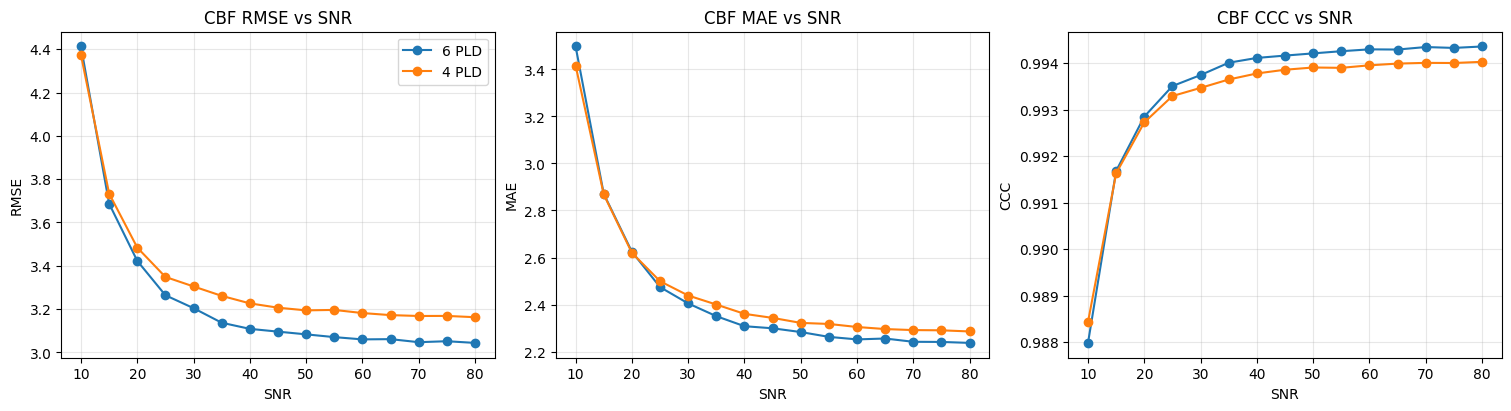

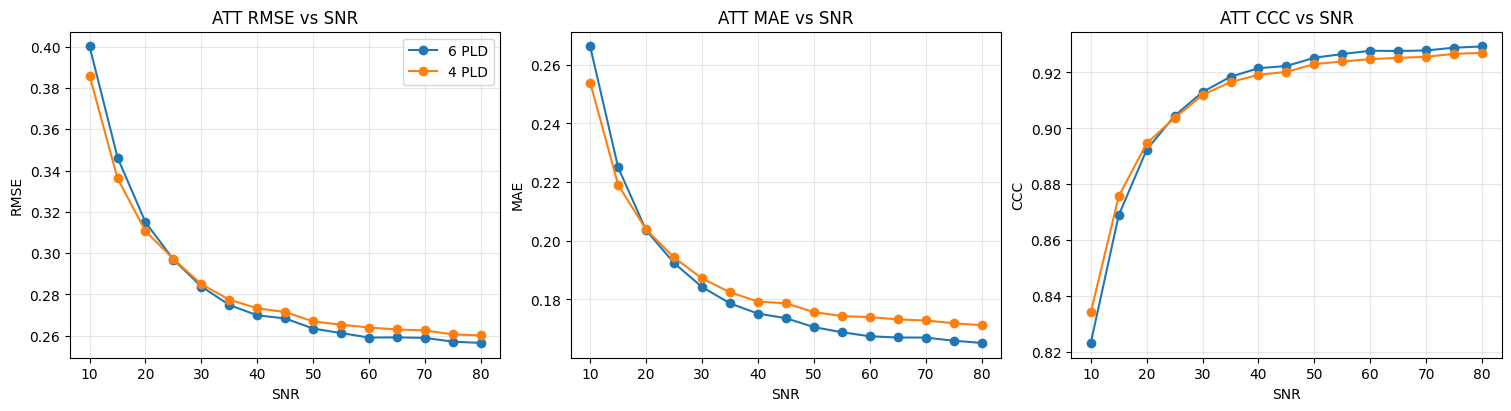

Plots saved to: D:\fiinal year project\dnn_pld_reduction\results\snr_10_to_80_plots


In [7]:
plot_dir = RESULTS / 'snr_10_to_80_plots'
plot_dir.mkdir(parents=True, exist_ok=True)
for parameter in ['CBF', 'ATT']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for axis, metric in zip(axes, ['RMSE', 'MAE', 'CCC']):
        subset = snr_metrics[snr_metrics.Parameter == parameter]
        for model_name in ['6 PLD', '4 PLD']:
            series = subset[subset.Model == model_name].sort_values('SNR')
            axis.plot(series.SNR, series[metric], 'o-', label=model_name)
        axis.set_xlabel('SNR'); axis.set_ylabel(metric); axis.set_title(f'{parameter} {metric} vs SNR'); axis.grid(alpha=0.3)
        if metric == 'RMSE': axis.legend()
    fig.savefig(plot_dir / f'{parameter.lower()}_snr_metrics.png', dpi=160)
    plt.show()
print('Plots saved to:', plot_dir)